In [22]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

In [24]:
df = pd.read_csv(
    "Amazon_Reviews.csv",
    encoding='latin-1',
    engine='python'
)

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up andâ¦,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [25]:
# BASIC INFORMATION

print(df.shape)

print(df.info())

print(df.describe(include='all'))

print(df.isnull().sum())

print(df.duplicated().sum())

(21214, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21214 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21055 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB
None
       Reviewer Name      Profile Link Country Review Count  \
count          21214             21163   21054        21055   
unique         18531             21156     148          177   
top         customer  January 21, 2012      US     1 review   
freq              72                 3    9286         5

In [26]:
# REMOVE DUPLICATES

df = df.drop_duplicates()

In [27]:
# CLEAN RATING COLUMN

df["Rating"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df["Rating"] = pd.to_numeric(
    df["Rating"],
    errors='coerce'
)

df["Rating"].head()

,Rating
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [28]:
# CREATE SENTIMENT COLUMN

def get_sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(get_sentiment)

df[["Rating","Sentiment"]].head()

,Rating,Sentiment
0,1.0,Negative
1,1.0,Negative
2,1.0,Negative
3,1.0,Negative
4,1.0,Negative


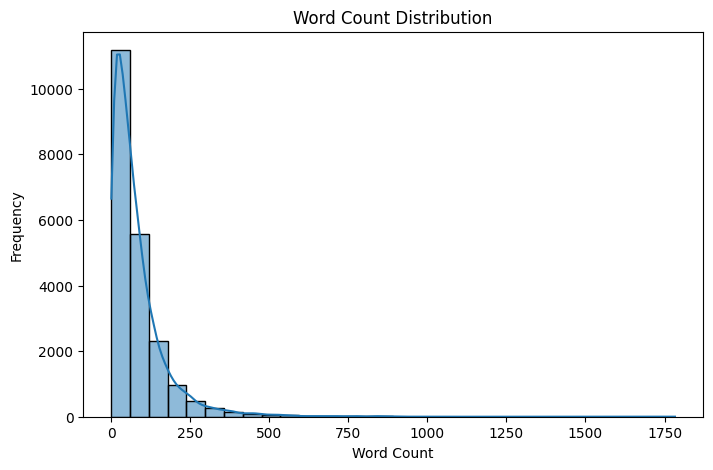

In [29]:
# WORD COUNT DISTRIBUTION

df["word_count"] = (
    df["Review Text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

plt.figure(figsize=(8,5))

sns.histplot(
    df["word_count"],
    bins=30,
    kde=True
)

plt.title("Word Count Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

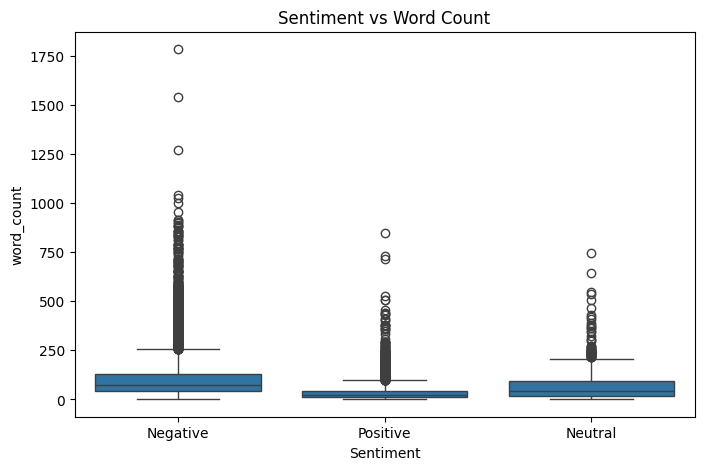

In [31]:
# SENTIMENT VS WORD COUNT

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Sentiment',
    y='word_count',
    data=df
)

plt.title("Sentiment vs Word Count")

plt.show()

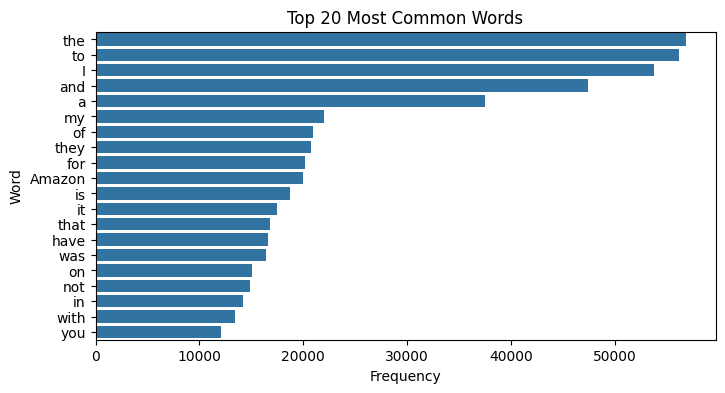

In [35]:
# TOP 20 MOST COMMON WORDS

from collections import Counter

all_words = ' '.join(
    df['Review Text']
    .astype(str)
).split()

common_words = (
    Counter(all_words)
    .most_common(20)
)

common_df = pd.DataFrame(
    common_words,
    columns=['Word','Frequency']
)

plt.figure(figsize=(8,4))

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_df
)

plt.title("Top 20 Most Common Words")

plt.show()

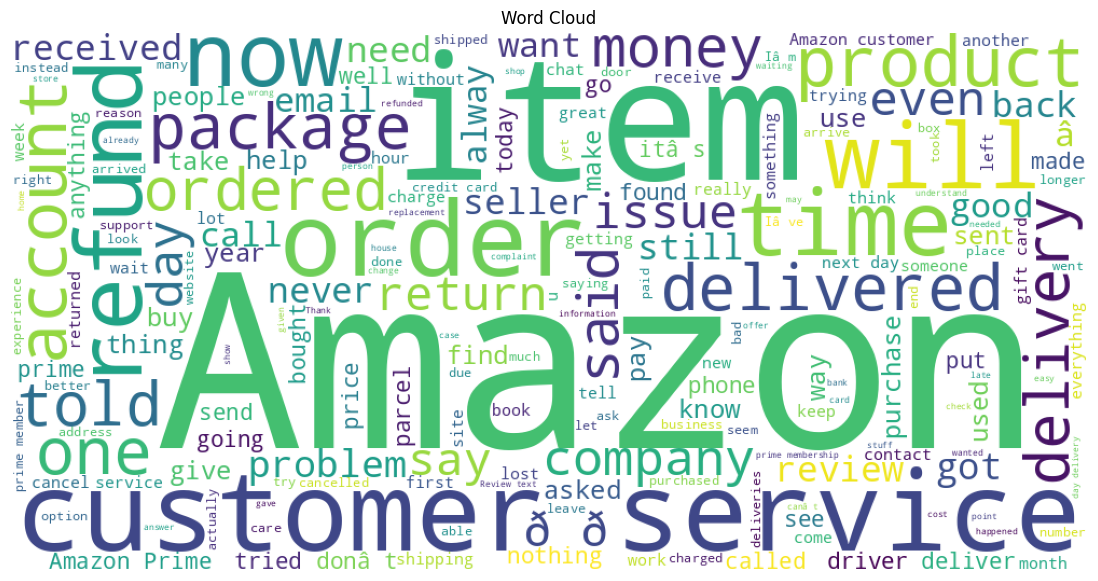

In [38]:
# WORD CLOUD

from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(
    ' '.join(
        df['Review Text']
        .astype(str)
    )
)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud")

plt.show()

In [47]:
# SENTENCE LENGTH

df["sentence_length"] = (
    df["Review Text"]
    .astype(str)
    .apply(len)
)

In [48]:
# WORD COUNT

df["word_count"] = (
    df["Review Text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

In [49]:
# AVERAGE WORD LENGTH

df["avg_word_length"] = (
    df["Review Text"]
    .astype(str)
    .apply(
        lambda x:
        np.mean(
            [len(word) for word in x.split()]
        )
        if len(x.split()) > 0
        else 0
    )
)

In [50]:
# PUNCTUATION DENSITY

import string

df["punct_density"] = (
    df["Review Text"]
    .astype(str)
    .apply(
        lambda x:
        sum(
            1 for char in x
            if char in string.punctuation
        ) / len(x)
        if len(x) > 0
        else 0
    )
)

In [51]:
# NEGATION FEATURE

neg_words = [
    "not",
    "no",
    "never",
    "none",
    "nothing",
    "n't"
]

df["negation"] = (
    df["Review Text"]
    .astype(str)
    .apply(
        lambda x:
        int(
            any(
                word in x.lower()
                for word in neg_words
            )
        )
    )
)

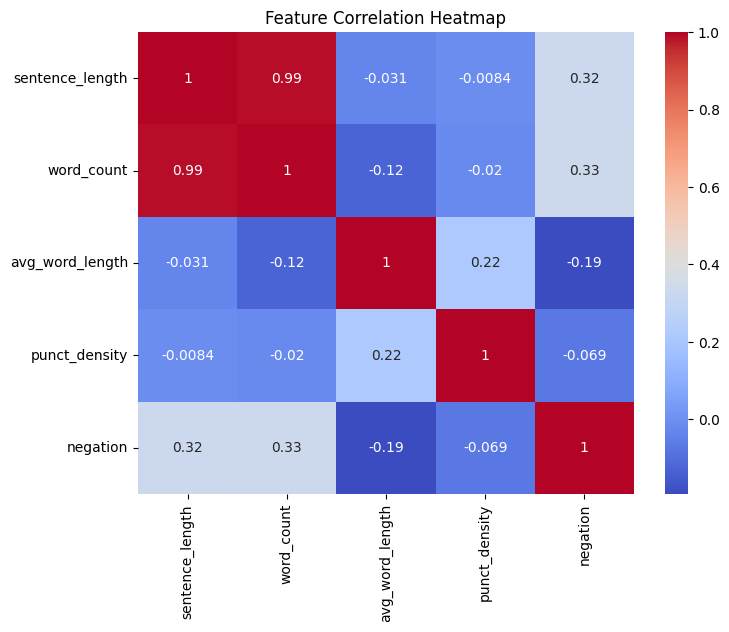

In [52]:
# FEATURE CORRELATION HEATMAP

numeric_df = df[
    [
        "sentence_length",
        "word_count",
        "avg_word_length",
        "punct_density",
        "negation"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()